# Tutorial: Bayesian Statistics Lab: Priors, Model Selection, and Posterior Inference

Federico Cerutti <federico.cerutti@unibs.it>

The notes are released with CC0. The code is MIT.

**Format of this notebook.** This notebook is designed as a self-guided lab. The code cells are intentionally compact and should be treated as the validated reference implementation. The teaching material therefore lives in the markdown: read the text first, inspect the code second, and only then run the cell.



**Useful references for students who want a formal API reference**
- [PyMC documentation](https://www.pymc.io/projects/docs/en/stable/learn.html)
- [ArviZ documentation](https://python.arviz.org/en/stable/)
- [SciPy statistical tests](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [statsmodels power analysis](https://www.statsmodels.org/stable/stats.html#power-and-sample-size)

**Main take-away for this lab**
- In the examples below, Bayesian analysis is more informative for decision making because it returns full uncertainty distributions and directly interpretable probabilities, not only a reject / fail-to-reject decision.


## 0. Environment setup and reading strategy


- The first code cell installs missing packages in a Colab-friendly way.
- The second code cell imports the libraries, fixes the global seed, and creates the random number generator used throughout the notebook.

As you read the import cell, classify the libraries by role:
- **classical statistics** (`scipy`, `statsmodels`),
- **Bayesian modeling and diagnostics** (`pymc`, `arviz`),
- **data handling and plotting** (`pandas`, `numpy`, `matplotlib`).


In [1]:
# Colab-friendly install cell.
# It only installs packages that are missing in the current runtime.
import subprocess
import sys

required = ["pymc", "arviz", "statsmodels"]
# ArviZ — works hand-in-hand with PyMC. After sampling, ArviZ gives you summaries (az.summary()), diagnostic plots, and model comparison (az.compare() with LOO). Think of it as the "results viewer" for PyMC.
# PyMC — this is the most important library to understand. It lets you define probabilistic models and sample from posteriors using NUTS (a modern MCMC algorithm). You'll see the with pm.Model() pattern everywhere.

import importlib.util
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print({"missing_before_install": missing, "required": required})


{'missing_before_install': [], 'required': ['pymc', 'arviz', 'statsmodels']}


In [2]:
from __future__ import annotations

import os
import random
import warnings
from math import lgamma

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
from scipy.stats import beta as beta_dist, gamma as gamma_dist
from statsmodels.stats.power import TTestIndPower

warnings.filterwarnings("ignore")
az.style.use("arviz-whitegrid")


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [3]:
# One global seed for deterministic notebook output.
SEED = 42

# SET SEED FOR OS ENVIRONMENT VARIABLES
os.environ["PYTHONHASHSEED"] = str(SEED)

# SET SEED FOR PYTHON'S BUILT-IN RANDOM MODULE
random.seed(SEED) # random.seed(SEED) sets the seed for Python's built-in random number generator, which is used by the random module. This ensures that any random operations performed using this module will produce the same results each time the code is run, as long as the seed is set to the same value.

# SET SEED FOR NUMPY'S RANDOM NUMBER GENERATOR (2 WAYS)
np.random.seed(SEED) # np.random.seed(SEED) sets the seed for NumPy's random number generator, which is used for any random operations performed using NumPy (e.g., np.random.rand, np.random.normal). This ensures that any random numbers generated by NumPy will be the same each time the code is run, as long as the seed is set to the same value.
RNG = np.random.default_rng(SEED) # RNG = np.random.default_rng(SEED) creates a new random number generator instance using NumPy's newer random API. 
# This is a more modern and flexible way to generate random numbers compared to the older np.random functions. By passing the seed to default_rng, you ensure that this specific generator will produce the same sequence of random numbers each time the code is run, as long as the seed is the same.

print({"seed": SEED})

{'seed': 42}


### Model specification (shared vs separate exponential rates)

Let \( y_i > 0 \) be observed response times and \( s_i \in \{1,2\} \) the system index.

---

#### Shared-rate model

Single rate parameter:

$$
\lambda \sim \text{Gamma}(\alpha, \beta)
$$

$$
y_i \mid \lambda \sim \text{Exponential}(\lambda), \quad i = 1,\dots,n
$$

Likelihood:

$$
p(\mathbf{y} \mid \lambda) = \prod_{i=1}^{n} \lambda \exp(-\lambda y_i)
$$

Posterior:

$$
p(\lambda \mid \mathbf{y}) \propto \lambda^{\alpha - 1 + n}
\exp\left(-\lambda \left(\beta + \sum_{i=1}^n y_i \right)\right)
$$

$$
\Rightarrow \lambda \mid \mathbf{y} \sim \text{Gamma}\left(\alpha + n,\; \beta + \sum_{i=1}^n y_i \right)
$$

---

#### Separate-rate model

Independent rates per system:

$$
\lambda_1, \lambda_2 \sim \text{Gamma}(\alpha, \beta)
$$

$$
y_i \mid \lambda_{s_i} \sim \text{Exponential}(\lambda_{s_i})
$$

Partition:

$$
\mathbf{y}_1 = \{y_i : s_i = 1\}, \quad
\mathbf{y}_2 = \{y_i : s_i = 2\}
$$

Posteriors:

$$
\lambda_1 \mid \mathbf{y}_1 \sim \text{Gamma}\left(\alpha + n_1,\; \beta + \sum_{y \in \mathbf{y}_1} y \right)
$$

$$
\lambda_2 \mid \mathbf{y}_2 \sim \text{Gamma}\left(\alpha + n_2,\; \beta + \sum_{y \in \mathbf{y}_2} y \right)
$$

---

#### Rate difference

$$
\Delta = \lambda_2 - \lambda_1
$$

(no closed form posterior; estimated via MCMC)

---

#### Probability system 2 is faster

$$
P(\lambda_2 > \lambda_1 \mid \mathbf{y})
\approx \frac{1}{M} \sum_{m=1}^M \mathbb{I}(\lambda_2^{(m)} > \lambda_1^{(m)})
$$


In [4]:
# Simulated positive response times from two systems.
cont_rng = np.random.default_rng(SEED + 101)

# GENERATIVE PROCESS: We are simulating response times for two systems using an exponential distribution, which is a common model for response times. The parameters we set (number of observations and true rate parameters) will allow us to create synthetic data that we can then analyze using Bayesian inference to compare the two systems based on their response times.
cont_n_1 = 45 # Number of observations for system 1. This could represent the number of response times we have recorded for system 1.
cont_n_2 = 45 # Number of observations for system 2. This could represent the number of response times we have recorded for system 2. By having the same number of observations for both systems, we can make a more balanced comparison between them when we analyze the data and infer their rate parameters.
cont_rate_1_true = 0.55 # The true rate parameter (lambda) for system 1. This is the underlying rate that we will use to simulate response times for system 1. A rate of 0.55 means that, on average, the expected time between events (response times) is 1 / 0.55 ≈ 1.82 units of time.
cont_rate_2_true = 0.80 # The true rate parameter (lambda) for system 2. This is the underlying rate that we will use to simulate response times for system 2. A rate of 0.80 means that, on average, the expected time between events (response times) is 1 / 0.80 = 1.25 units of time. Since this rate is higher than that of system 1, we would expect system 2 to have faster response times on average compared to system 1.

# LIKELIHOOD: We simulate response times for both systems using an exponential distribution, which is a common model for response times. The scale parameter for the exponential distribution is the inverse of the rate (1 / lambda), so we set scale=1 / cont_rate_1_true for system 1 and scale=1 / cont_rate_2_true for system 2. We generate cont_n_1 samples for system 1 and cont_n_2 samples for system 2 to represent the observed response times for each system. This simulated data will be used to perform Bayesian inference and compare the two systems based on their response times.
cont_times_1 = cont_rng.exponential(scale=1 / cont_rate_1_true, size=cont_n_1) # We simulate response times for system 1 using an exponential distribution with the true rate parameter cont_rate_1_true. The scale parameter for the exponential distribution is the inverse of the rate (1 / lambda), so we set scale=1 / cont_rate_1_true. We generate cont_n_1 samples to represent the observed response times for system 1.
cont_times_2 = cont_rng.exponential(scale=1 / cont_rate_2_true, size=cont_n_2) # We simulate response times for system 2 using an exponential distribution with the true rate parameter cont_rate_2_true. The scale parameter for the exponential distribution is the inverse of the rate (1 / lambda), so we set scale=1 / cont_rate_2_true. We generate cont_n_2 samples to represent the observed response times for system 2.
cont_all_times = np.concatenate([cont_times_1, cont_times_2]) # We combine the response times from both systems into a single array cont_all_times. This will allow us to analyze the data together and to use the system index to differentiate between the two groups when we perform our Bayesian inference and comparisons.
cont_system_idx = np.array([0] * cont_n_1 + [1] * cont_n_2) # We create an index array cont_system_idx that indicates which system each response time belongs to. The first cont_n_1 entries are 0 (indicating system 1), and the next cont_n_2 entries are 1 (indicating system 2). This will allow us to use this index in our Bayesian model to differentiate between the two groups when we analyze the data and infer their rate parameters.


---

Il posteriore ha una formula chiusa — puoi calcolarlo direttamente come hai fatto prima, Ma nella realtà i modelli sono più complessi: più variabili, relazioni non lineari, prior non coniugati. In quei casi non esiste formula chiusa per il posteriore. La soluzione è campionare il posteriore numericamente — generare migliaia di valori casuali distribuiti secondo il posteriore, senza conoscerne la formula esatta.

In quel caso non esiste più una formula per il posteriore. PyMC esplora lo spazio dei parametri con NUTS e raccoglie campioni che approssimano il posteriore — senza aver bisogno della formula.
NUTS (No-U-Turn Sampler) è una versione avanzata di MCMC che sceglie i passi in modo molto più efficiente — non spreca passi tornando dove è già stato.

Un modello è semplicemente una storia su come i dati sono stati generati.
 Punto. Non è necessariamente una rete neurale o un algoritmo di ML. È qualsiasi descrizione matematica di come credi che i dati siano stati prodotti.


In [5]:
cont_prior_alpha = 2.0
cont_prior_beta = 2.0

# PYMC MODEL: We define a Bayesian model using PyMC to analyze the response times from both systems. 
# We specify a shared rate parameter (cont_rate_shared) that follows a Gamma distribution with the specified prior parameters (cont_prior_alpha and cont_prior_beta). The observed response times (cont_all_times) are modeled as being drawn from an Exponential distribution with the shared rate parameter. By using a shared rate parameter, we are essentially assuming that both systems have the same underlying rate, and we will use the data to update our beliefs about this common rate. After defining the model, we sample from the posterior distribution using MCMC to obtain estimates of the rate parameter based on the observed data.
with pm.Model() as cont_shared_model: 
    # LIKELIHOOD: We define the likelihood of the observed data given the model parameters. In this case, we assume that the response times (cont_all_times) are drawn from an Exponential distribution with a shared rate parameter (cont_rate_shared). This means that we are modeling the response times from both systems as coming from the same underlying exponential distribution, which allows us to infer a common rate parameter based on the combined data from both systems.
    cont_rate_shared = pm.Gamma("rate", alpha=cont_prior_alpha, beta=cont_prior_beta)
    # PRIOR: We specify a shared rate parameter (cont_rate_shared) that follows a Gamma distribution with the specified prior parameters (cont_prior_alpha and cont_prior_beta). This represents our initial beliefs about the rate parameter before observing the data. The Gamma distribution is a common choice for the prior of a rate parameter in an exponential model because it is conjugate to the exponential likelihood, which simplifies the Bayesian updating process.
    pm.Exponential("obs", lam=cont_rate_shared, observed=cont_all_times)
    cont_idata_shared = pm.sample(
        draws=600, 
        tune=600,
        chains=2,
        cores=1,
        random_seed=SEED,
        target_accept=0.9,
        progressbar=False,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rate]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [6]:
# PYMC MODEL: We define a Bayesian model using PyMC to analyze the response times from both systems. 
# In this model, we specify separate rate parameters for each system (cont_rates) that follow a Gamma distribution with the specified prior parameters (cont_prior_alpha and cont_prior_beta). The observed response times (cont_all_times) are modeled as being drawn from an Exponential distribution with the corresponding rate parameter for each system, determined by cont_system_idx. By allowing separate rate parameters for each system, we can infer whether there is a difference in the underlying rates of the two systems based on the observed data. After defining the model, we sample from the posterior distribution using MCMC to obtain estimates of the rate parameters for both systems and to compare them.
with pm.Model(coords={"system": ["system_1", "system_2"]}) as cont_separate_model:
    # LIKELIHOOD: We define the likelihood of the observed data given the model parameters. In this case, we assume that the response times (cont_all_times) are drawn from an Exponential distribution with separate rate parameters for each system (cont_rates). The specific rate parameter used for each observation is determined by cont_system_idx, which indicates which system each response time belongs to. This allows us to model the response times from each system as coming from different exponential distributions, which enables us to infer separate rate parameters for each system based on the observed data.
    cont_rates = pm.Gamma("rate", alpha=cont_prior_alpha, beta=cont_prior_beta, dims="system")
    cont_rate_gap = pm.Deterministic("rate_gap", cont_rates[1] - cont_rates[0]) # lambda_2 - lambda_1, where lambda_1 is the rate for system 1 and lambda_2 is the rate for system 2. This deterministic variable allows us to directly compute the difference in rates between the two systems, which can be useful for assessing whether one system has a significantly different rate than the other based on the posterior distribution of this gap.
    # PRIOR: We specify separate rate parameters for each system (cont_rates) that follow a Gamma distribution with the specified prior parameters (cont_prior_alpha and cont_prior_beta). This represents our initial beliefs about the rate parameters for each system before observing the data. By allowing separate rate parameters, we can capture the possibility that the two systems have different underlying rates, and we will use the data to update our beliefs about these parameters.
    pm.Exponential("obs", lam=cont_rates[cont_system_idx], observed=cont_all_times)
    cont_idata_separate = pm.sample(
        draws=600, # Number of MCMC samples to draw from the posterior distribution for each chain. This determines how many samples we will have to estimate the posterior distribution of the parameters. A higher number of draws can lead to a more accurate estimate of the posterior, but it also increases the computational time.
        tune=600, # Number of tuning (or "burn-in") steps to perform before starting to collect samples. During the tuning phase, the MCMC sampler adjusts its parameters to better explore the posterior distribution. These samples are not included in the final analysis, as they are used to help the sampler converge to the target distribution.
        chains=2, # Number of independent MCMC chains to run. Running multiple chains helps assess the convergence of the sampler and provides a more robust estimate of the posterior distribution.
        cores=1, # Number of CPU cores to use for parallel computation. Using multiple cores can speed up the sampling process.
        random_seed=SEED, # Setting the random seed ensures that the results are reproducible. By using the same seed, you will get the same sequence of random numbers and therefore the same samples from the posterior distribution each time you run the code.
        target_accept=0.9, # This is the target acceptance rate for the NUTS sampler. A value of 0.9 means that we want the sampler to accept 90% of the proposed samples. Setting a higher target_accept can lead to more conservative sampling and can help with convergence, especially in models with complex posteriors.
        progressbar=False, # Whether to display a progress bar during sampling. Setting this to False will suppress the progress bar output, which can be useful in environments where you want cleaner output or when running long sampling processes.
        idata_kwargs={"log_likelihood": True}, # Whether to include the log likelihood in the InferenceData object returned by pm.sample. Setting this to True allows us to access the log likelihood values for each sample, which can be useful for model comparison and diagnostics.
    )


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rate]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 19 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [7]:
# output di ArviZ summary tables for both models, showing the posterior mean and 95% HDI for the rate parameters. The cont_shared_summary will show the summary for the shared rate parameter in the first model, while the cont_separate_summary will show the summaries for the separate rate parameters and the rate gap in the second model. This allows us to compare the inferred rates for both systems and to assess whether there is a significant difference between them based on the posterior distribution of the rate gap.
cont_shared_summary = az.summary(cont_idata_shared, var_names=["rate"], hdi_prob=0.95)
cont_separate_summary = az.summary(cont_idata_separate, var_names=["rate", "rate_gap"], hdi_prob=0.95)
display(cont_shared_summary)
display(cont_separate_summary)

cont_rate_draws = (
    cont_idata_separate.posterior["rate"] # type: ignore
    .stack(sample=("chain", "draw"))
    .transpose("sample", "system")
    .values
)
cont_prob_system_2_faster = float(np.mean(cont_rate_draws[:, 1] > cont_rate_draws[:, 0]))


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rate,0.553,0.059,0.438,0.668,0.003,0.002,420.0,510.0,1.01


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rate[system_1],0.409,0.061,0.293,0.528,0.002,0.002,942.0,646.0,1.0
rate[system_2],0.893,0.132,0.652,1.152,0.004,0.004,1353.0,894.0,1.0
rate_gap,0.484,0.148,0.203,0.792,0.004,0.005,1166.0,796.0,1.0


{'P(system 2 faster | data)': 1.0, 'observed mean time system 1': np.float64(2.501225557691541), 'observed mean time system 2': np.float64(1.119775101509364)}


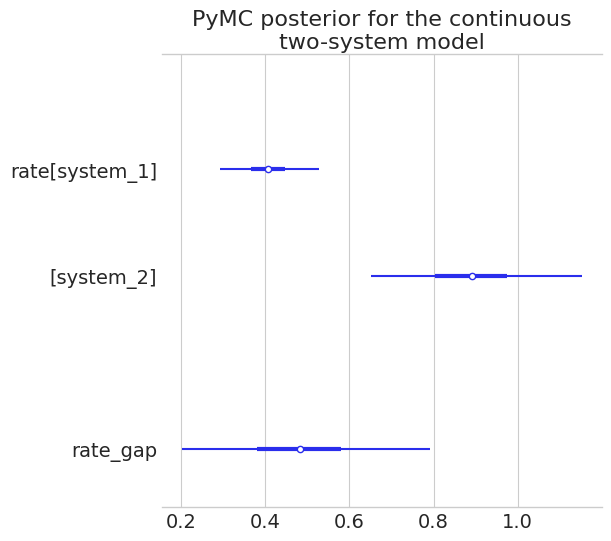

In [8]:
print(
    {
        "P(system 2 faster | data)": cont_prob_system_2_faster,
        "observed mean time system 1": cont_times_1.mean(),
        "observed mean time system 2": cont_times_2.mean(),
    }
)

az.plot_forest(cont_idata_separate, var_names=["rate", "rate_gap"], combined=True, hdi_prob=0.95)
plt.title("PyMC posterior for the continuous two-system model");

### Reading the continuous comparison

The shared model is the "indistinguishable systems" story: both systems are forced to share one positive rate.
The separate model is the "distinguishable systems" story: each system gets its own rate and can explain different response-time behavior directly.
PyMC gives posterior draws, and ArviZ turns them into summaries and a forest plot.

### Exercises

1. Move the two true rates closer together. How quickly do the posterior curves overlap?
2. Cut the sample sizes in half. What happens to the width of the posterior summaries?
3. Replace the `Gamma(2, 2)` prior with a more skeptical `Gamma(8, 8)` prior. How much do the posteriors move?


### L'overfitting non è un problema solo del ML. È un problema universale di qualsiasi modello con parametri.

---

Il modello con 2 parametri ha più libertà — può adattarsi meglio ai dati osservati quasi per definizione. Ma quella libertà extra potrebbe star imparando il rumore specifico di quei 90 dati, non il pattern reale.


Un modello con più parametri si adatta sempre meglio ai dati che ha già visto. Il modello separato ha 2 parametri (λ₁, λ₂) contro 1 del modello condiviso — quindi si adatterà sempre meglio ai dati osservati, per definizione.

Ma questo non significa che sia migliore. Potrebbe star imparando il rumore dei dati invece dei pattern reali — e quindi fare previsioni peggiori su dati nuovi che non ha mai visto.

L'esempio estremo: un modello con 40 parametri su 40 dati si adatta perfettamente ai dati osservati (errore zero), ma non generalizza a nulla.


## 4. Model selection on continuous measurements with LOO

Parameter inference asks: **how large is the rate inside a chosen model?**

Model comparison asks: **is it worth keeping two separate rates, or is one shared rate enough?**

Because we already sampled both models with PyMC, ArviZ can compare their expected out-of-sample performance with LOO. That is the Monte Carlo version of the same model-selection question.

**Before running the next cell**
- The shared model uses one posterior rate.
- The separate model uses two rates and one rate gap.
- Predict whether the extra flexibility will pay off.


L'idea è semplice: per ogni osservazione i, nascondi quel dato, addestra il modello sul resto, e vedi quanto bene prevede il dato nascosto.


#### LOO model comparison

$$
\text{ELPD}_{\text{LOO}} = \sum_{i=1}^n \log p(y_i \mid \mathbf{y}_{-i})
$$

Higher values indicate better predictive performance.

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
separate_rates,0,-138.443965,2.086269,0.000000,0.906091,10.588243,0.000000,False,log
shared_rate,1,-144.531917,1.168592,6.087952,0.093909,10.244851,3.750186,False,log


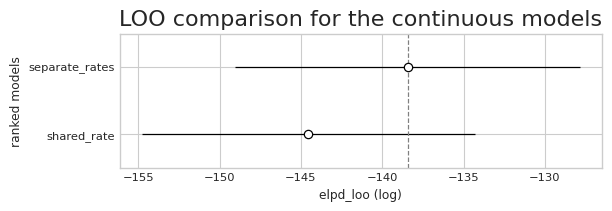

In [ ]:
cont_compare = az.compare(
    {"shared_rate": cont_idata_shared, "separate_rates": cont_idata_separate},
    ic="loo",
)
# az.compare() is a function from the ArviZ library that allows us to compare different models based on their information criteria, such as LOO (Leave-One-Out cross-validation). In this case, we are comparing the "shared_rate" model (where both systems share the same rate parameter) and the "separate_rates" model (where each system has its own rate parameter) using LOO. The resulting cont_compare object will contain the comparison results, including the LOO values and weights for each model, which can help us assess which model better explains the observed data.
# cont_idata_shared and cont_idata_separate are the InferenceData objects returned by pm.sample() for the shared rate model and the separate rates model, respectively. By passing these objects to az.compare(), we can compare the two models based on their LOO values, which provide an estimate of the out-of-sample predictive performance of each model. The model with the lower LOO value is generally considered to have better predictive performance, and the weights can help us understand the relative support for each model given the data.

display(cont_compare)
az.plot_compare(cont_compare)
plt.title("LOO comparison for the continuous models");


### Interpreting the comparison table

LOO ranks the model that is expected to predict new data better.
If `elpd_diff` is large relative to `dse`, the separate-rate model is doing real work.
If `elpd_diff` is tiny, the shared model is already enough.

Caso 1 — elpd_diff grande rispetto a dse:
separate_rates   elpd_loo=-45   elpd_diff=0    dse=0
shared_rate      elpd_loo=-60   elpd_diff=15   dse=4
La differenza (15) è molto più grande dell'errore standard (4) → il modello separato vale davvero qualcosa in più → i due sistemi sono probabilmente diversi.

Caso 2 — elpd_diff piccolo rispetto a dse:
shared_rate      elpd_loo=-50   elpd_diff=0    dse=0
separate_rates   elpd_loo=-51   elpd_diff=1    dse=3
La differenza (1) è molto più piccola dell'errore standard (3) → i due modelli predicono praticamente uguale → conviene il più semplice (modello condiviso).
p_loo ti dà un'idea della complessità effettiva del modello. Se p_loo del modello separato è circa 2 (due parametri reali), il modello sta usando davvero entrambi i parametri. Se fosse molto più alto, potrebbe essere un segnale di problemi.

### Exercises

1. Move `cont_rate_2_true` closer to `cont_rate_1_true` and rerun the code. Does the comparison become less decisive?
2. Cut the sample sizes in half. What happens to the rank gap?
3. Tighten the prior to `Gamma(8, 8)`. Does the stronger prior pull the posteriors together?
